In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
arr = np.random.randint(0, 10, size=5)
arr

array([2, 6, 5, 8, 3])

In [3]:
double = np.zeros(5, dtype=int)
double

array([0, 0, 0, 0, 0])

In [4]:
%%timeit -r 3
for i in range(5):
    double[i] = arr[i] + arr[i]

1.04 μs ± 127 ns per loop (mean ± std. dev. of 3 runs, 1,000,000 loops each)


In [5]:
%%timeit -r 3
arr + arr

274 ns ± 0.398 ns per loop (mean ± std. dev. of 3 runs, 1,000,000 loops each)


In [6]:
import torch
import math

torch.manual_seed(42)

In [7]:
t_cpu = torch.rand((200,300))
t_mps = torch.rand((200, 300), device="mps")
t_cpu, t_mps

(tensor([[0.8823, 0.9150, 0.3829,  ..., 0.4610, 0.3335, 0.3382],
         [0.5161, 0.3939, 0.3278,  ..., 0.0599, 0.8489, 0.5579],
         [0.2305, 0.7613, 0.0268,  ..., 0.2944, 0.3762, 0.3067],
         ...,
         [0.7485, 0.3485, 0.1021,  ..., 0.6360, 0.8178, 0.1768],
         [0.3328, 0.1571, 0.5348,  ..., 0.0269, 0.3345, 0.0960],
         [0.9726, 0.6750, 0.6891,  ..., 0.0299, 0.8939, 0.6540]]),
 tensor([[0.8172, 0.5881, 0.5581,  ..., 0.9032, 0.2341, 0.6098],
         [0.9482, 0.9945, 0.2745,  ..., 0.8708, 0.2987, 0.3742],
         [0.9608, 0.4463, 0.2992,  ..., 0.9045, 0.0824, 0.5939],
         ...,
         [0.8308, 0.9432, 0.6459,  ..., 0.9506, 0.9557, 0.1394],
         [0.7880, 0.3229, 0.5933,  ..., 0.2353, 0.3144, 0.0638],
         [0.4213, 0.3442, 0.0748,  ..., 0.4319, 0.2706, 0.4701]],
        device='mps:0'))

In [8]:
%%timeit
t_cpu + t_cpu

21.2 μs ± 1.26 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [9]:
%%timeit
t_mps + t_mps

1.76 μs ± 23.1 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [10]:
device = torch.device("cpu")
dtype = torch.float

In [11]:
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)
x, y

(tensor([-3.1416, -3.1384, -3.1353,  ...,  3.1353,  3.1384,  3.1416]),
 tensor([ 8.7423e-08, -3.1430e-03, -6.2863e-03,  ...,  6.2863e-03,
          3.1430e-03, -8.7423e-08]))

In [12]:
def initialize_weights():
    a = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    b = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    c = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    d = torch.randn((), device=device, dtype=dtype, requires_grad=True)
    return a, b, c, d

In [13]:
wa, wb, wc, wd = initialize_weights()
wa, wb, wc, wd

(tensor(1.2376, requires_grad=True),
 tensor(-0.6796, requires_grad=True),
 tensor(-0.2996, requires_grad=True),
 tensor(1.0826, requires_grad=True))

In [14]:
a, b, c, d = (
    w.detach().clone().requires_grad_()
    for w in (wa, wb, wc, wd)
)
lr = 1e-6
for t in range(2000):
    y_pred = a + b * x + c * x** 2 + d * x **3
    loss = (y_pred - y).pow(2).sum()

    if t == 0:
        initial_loss = loss.item()

    if t % 100 == 0:
        print(t, loss.item())

    loss.backward()

    with torch.no_grad():
        a -= lr * a.grad
        b -= lr * b.grad
        c -= lr * c.grad
        d -= lr * d.grad

        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(a.item(), b.item(), c.item(), d.item())

0 257134.953125
100 2938.629638671875
200 1991.94580078125
300 1352.564697265625
400 920.3005981445312
500 627.7623291015625
600 429.5778503417969
700 295.1712341308594
800 203.91903686523438
900 141.89749145507812
1000 99.69615173339844
1100 70.94869232177734
1200 51.34368133544922
1300 37.958335876464844
1400 28.808944702148438
1500 22.547771453857422
1600 18.25819206237793
1700 15.31592845916748
1800 13.295572280883789
1900 11.90666389465332
0.03943123295903206 0.8300518989562988 -0.006802544463425875 -0.08953411877155304


In [15]:
a, b, c, d = (
    w.detach().clone().requires_grad_()
    for w in (wa, wb, wc, wd)
)
lr = 1e-6
optimizer = torch.optim.SGD([a, b, c, d], lr=lr)

for t in range(2000):
    y_pred = a + b * x + c * x** 2 + d * x **3
    loss = (y_pred - y).pow(2).sum()

    if t % 100 == 0:
        print(t, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(a.item(), b.item(), c.item(), d.item())

0 257134.953125
100 2938.629638671875
200 1991.94580078125
300 1352.5648193359375
400 920.300537109375
500 627.7623291015625
600 429.57781982421875
700 295.17120361328125
800 203.91903686523438
900 141.89749145507812
1000 99.69615173339844
1100 70.94869232177734
1200 51.34368133544922
1300 37.958335876464844
1400 28.808950424194336
1500 22.547771453857422
1600 18.25819206237793
1700 15.315927505493164
1800 13.295570373535156
1900 11.90666389465332
0.03943123295903206 0.8300518989562988 -0.006802544463425875 -0.08953411877155304


In [16]:
class TinyNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(in_features=1, out_features=10)
        self.linear2 = torch.nn.Linear(in_features=10, out_features=1)
        self.linear_relu = torch.nn.Sequential(
            self.linear1,
            torch.nn.ReLU(),
            self.linear2
        )

    def forward(self, x):
        return self.linear_relu(x)

In [17]:
model = TinyNN()

In [18]:
model.parameters()

<generator object Module.parameters at 0x366c65460>

In [19]:
total_params = sum([p.numel() for p in model.parameters()])
trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
total_params, trainable_params

(31, 31)

In [20]:
x.shape, y.shape

(torch.Size([2000]), torch.Size([2000]))

In [21]:
model(x[:, None]).shape

torch.Size([2000, 1])

In [22]:
lr = 1e-1
loss_fn = torch.nn.MSELoss()

model = TinyNN()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
snapshots = {}
checkpoints = {0, 10, 50, 200, 700, 1999}

model.train()
for t in range(2000):
    y_pred = model(x[:, None])
    loss = loss_fn(y_pred, y[:, None])

    if t % 100 == 0:
        print(t, loss.item())

    if t in checkpoints:
        snapshots[t] = y_pred.detach().cpu().squeeze(-1).numpy().copy()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(model.parameters())

0 0.9035443067550659
100 0.12254214286804199
200 0.05576694384217262
300 0.025562239810824394
400 0.012590513564646244
500 0.008332747966051102
600 0.00622168742120266
700 0.020449236035346985
800 0.004197544883936644
900 0.003317610826343298
1000 0.002650346839800477
1100 0.00211257953196764
1200 0.0016975790495052934
1300 0.0013980724615976214
1400 0.001195227145217359
1500 0.001063485280610621
1600 0.000979177886620164
1700 0.0009245812543667853
1800 0.0008880987297743559
1900 0.0008625398622825742
<generator object Module.parameters at 0x366c65d20>


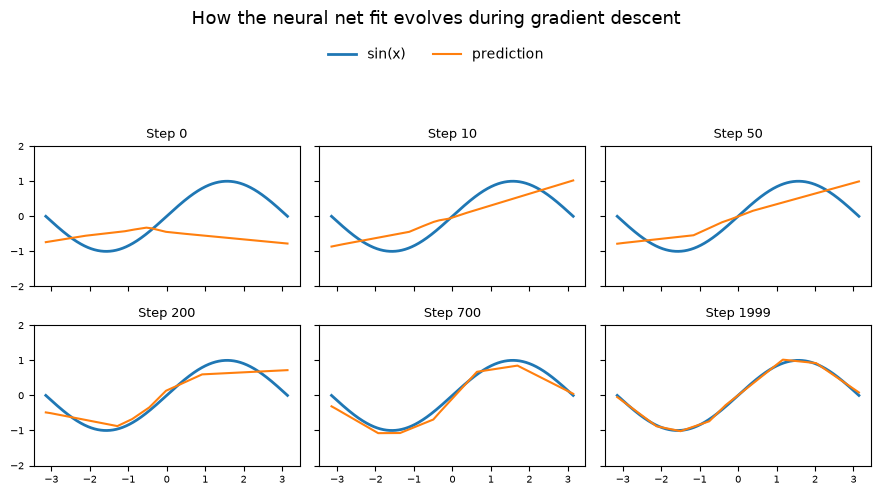

In [23]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(9, 5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (t, y_pred_snapshot) in zip(axes, snapshots.items()):
    ax.plot(x, y, label="sin(x)", linewidth=2)
    ax.plot(x, y_pred_snapshot, label="prediction")

    ax.set_title(f"Step {t}", fontsize=9)
    ax.set_ylim(-2, 2)
    ax.tick_params(labelsize=7)

# Main title
fig.suptitle(
    "How the neural net fit evolves during gradient descent",
    fontsize=13,
    y=0.98
)

# Shared legend below title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=2,
    frameon=False
)

# Leave space at top for title + legend
plt.tight_layout(rect=[0, 0, 1, 0.84])

plt.show()